In [1]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
import scanpy as sc
import numpy as np
import pandas as pd
#import cv2
import math
from pathlib import Path, PurePath
from scipy.spatial import distance
from scipy.ndimage import gaussian_filter
from typing import Union, Dict, Optional, Tuple, BinaryIO
import json

from PIL import Image

In [2]:
def QC(tissue_dir):
    metafile = None
    adata1 = sc.read_visium(tissue_dir) 
    
    adata1.var_names_make_unique() 
    #sc.pp.normalize_total(adata1, inplace=True) 
    sc.pp.log1p(adata1)
    adata1.obs['n_counts'] = adata1.X.sum(axis=1).A1
    sc.pl.spatial(adata1, img_key="hires", color='n_counts', alpha=0.7, cmap='jet')

    return adata1

In [3]:
tissue_dir = './OSCC_2_human_16S_rRNA/outs'
# CRC_16_human_16S_rRNA
# OSCC_Ecoli+Human
metafile = None

/home/seohyepark/yes/envs/CellDART/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


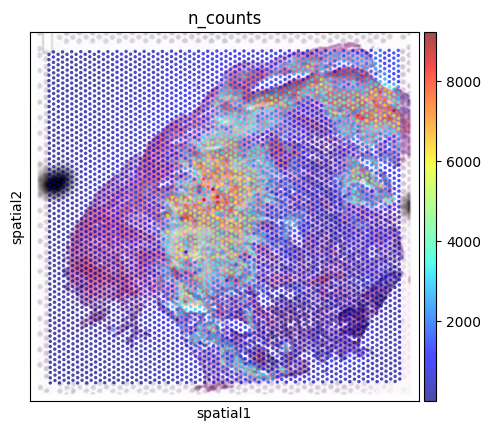

In [4]:
adata1 = QC(tissue_dir)

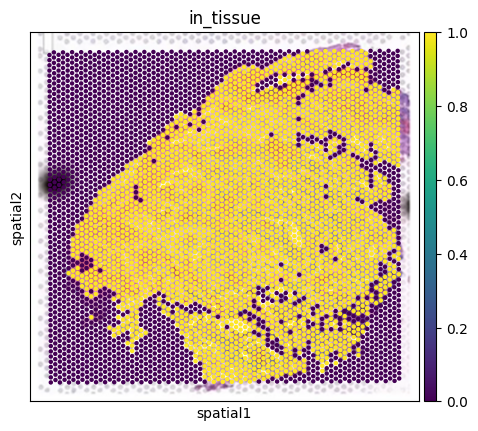

In [7]:
import pandas as pd
import scanpy as sc

# CRC_mask.csv 파일 읽기
mask_df = pd.read_csv('./OSCC_2_human_16S_rRNA/outs/OSCC_mask.csv', index_col=0)

# adata1.obs에 mask 정보 추가하기
adata1.obs['mask'] = mask_df['mask_in']

# 'in_tissue' 열에서 'In'은 1로, 'Out'은 0으로 매핑합니다.
adata1.obs['in_tissue'] = adata1.obs['mask'].apply(lambda x: 1 if x == 'In' else 0)

# Spatial plot 그리기, 'in_tissue'에 따라 색상을 다르게 지정
sc.pl.spatial(adata1, color='in_tissue', spot_size=20)


In [14]:
adata1.obs

,in_tissue,array_row,array_col,n_counts,mask
AAACAACGAATAGTTC-1,1,0,16,2995.446777,In
AAACAAGTATCTCCCA-1,1,50,102,1849.946045,In
AAACAATCTACTAGCA-1,0,3,43,1762.702637,Out
AAACACCAATAACTGC-1,0,59,19,441.179443,Out
AAACAGAGCGACTCCT-1,1,14,94,378.436981,In
...,...,...,...,...,...
TTGTTTCACATCCAGG-1,1,58,42,523.403320,In
TTGTTTCATTAGTCTA-1,0,60,30,318.184235,Out
TTGTTTCCATACAACT-1,1,45,27,1652.234131,In
TTGTTTGTATTACACG-1,0,73,41,93.329147,Out


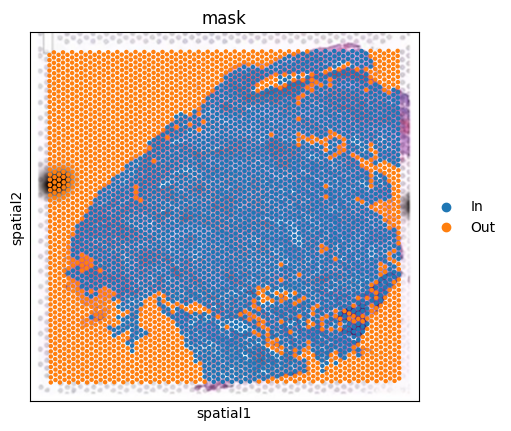

In [16]:
import pandas as pd
import scanpy as sc

# CRC_mask.csv 파일 읽기
mask_df = pd.read_csv('./OSCC_2_human_16S_rRNA/outs/OSCC_mask.csv', index_col=0)

# adata1.obs에 mask 정보 추가하기
adata1.obs['mask'] = mask_df['mask_in']
adata1.obs['mask'] = adata1.obs['mask'].fillna('Out')

# 'in_tissue' 열에서 'In'은 1로, 'Out'은 0으로 매핑합니다.
adata1.obs['in_tissue'] = adata1.obs['mask'].apply(lambda x: 1 if x == 'In' else 0)

# Spatial plot 그리기, 'In'과 'Out'에 따라 색상을 다르게 지정
sc.pl.spatial(adata1, color='mask', spot_size=20)


In [17]:
adata=adata1

In [18]:
# 'in_tissue' 열에서 'In'은 1로, 'Out'은 0으로 매핑합니다.
adata.obs['in_tissue'] = adata.obs['mask'].apply(lambda x: 1 if x == 'In' else 0)
adata.obs['in_tissue'] = adata.obs['in_tissue'].astype(int)

# 결과를 확인합니다.
print(adata.obs.head())


                    in_tissue  array_row  array_col     n_counts mask
AAACAACGAATAGTTC-1          1          0         16  2995.446777   In
AAACAAGTATCTCCCA-1          1         50        102  1849.946045   In
AAACAATCTACTAGCA-1          0          3         43  1762.702637  Out
AAACACCAATAACTGC-1          0         59         19   441.179443  Out
AAACAGAGCGACTCCT-1          1         14         94   378.436981   In


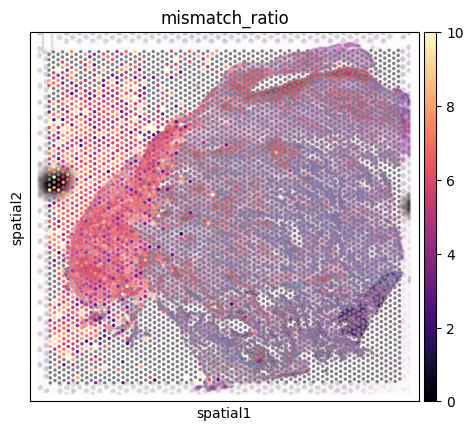

In [19]:
df = pd.read_csv(tissue_dir + '/barcode_summary.csv', index_col = 0)

adata.obs['all_RNA_reads'] = df['l2']
adata.obs['mean_num_of_mismatches'] = df['l3']

adata.obs['mismatch_ratio'] = adata.obs['mean_num_of_mismatches'] / adata.obs['all_RNA_reads']

adata.obs['mismatch_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
adata.obs['mismatch_ratio'].fillna(-1, inplace=True)

cmap = plt.cm.magma# You can choose any other colormap
cmap.set_under('gray')  # Setting the color for -1 values

sc.pl.spatial(adata, color='mismatch_ratio', save = '.png', cmap=cmap,  vmax = 10, vmin=0)

import matplotlib.pyplot as plt
import scanpy as sc

In [20]:
adata.obs['mismatch_ratio'] = adata.obs['mean_num_of_mismatches'] / adata.obs['all_RNA_reads']
adata.obs['mismatch_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
adata.obs['mismatch_ratio'].fillna(-1, inplace=True)

cmap = plt.cm.gist_stern  # You can choose any other colormap
cmap.set_under('gray')  # Setting the color for -1 values


[<Axes: title={'center': 'mismatch_ratio'}, xlabel='spatial1', ylabel='spatial2'>]

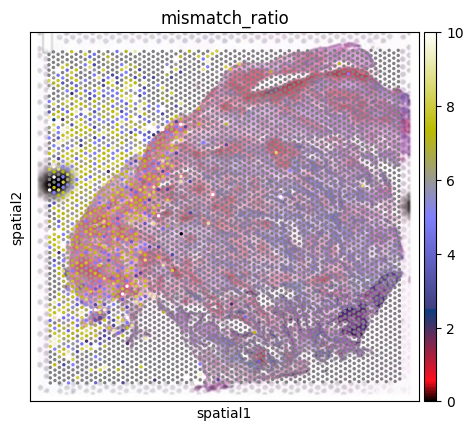

In [21]:
# Create the plot
sc.pl.spatial(adata, color='mismatch_ratio', cmap=cmap, vmax = 10, vmin=0, show=False)



<Figure size 640x480 with 0 Axes>

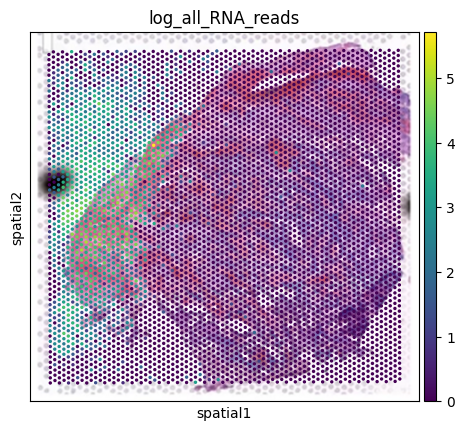

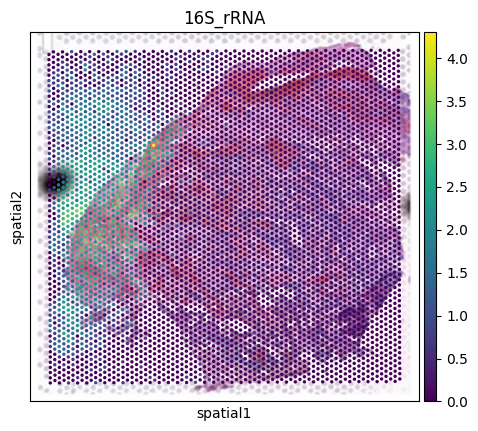

In [23]:
# Save the figure in high resolution
plt.savefig('spatial_plot.png', dpi=300)  # 300 dpi is typically considered high resolution

adata.obs['log_all_RNA_reads'] = np.log1p(adata.obs['all_RNA_reads'])
sc.pl.spatial(adata, color='log_all_RNA_reads')

sc.pl.spatial(adata, color='16S_rRNA')

tissue_positions_df = pd.read_csv('~/_Nature/OSCC_2_human_16S_rRNA/outs/spatial/tissue_positions_list.csv')

In [25]:
tissue_positions_df = pd.read_csv('./OSCC_2_human_16S_rRNA/outs/spatial/tissue_positions_list.csv')


In [37]:
from scipy.spatial import distance
import numpy as np

# array_row와 array_col을 기반으로 모든 샘플 간의 거리를 계산합니다.
coords = adata.obs[['array_row', 'array_col']].values
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# in_tissue의 총 합을 계산합니다.
total_in_tissue = adata.obs['in_tissue'].sum()

# 조건을 만족하는 최소 이웃의 수를 찾기 위한 변수를 초기화합니다.
min_neighbors = 1
condition_met = False

# 조건을 만족할 때까지 이웃의 수를 증가시키면서 반복합니다.
for n_neighbors in range(1, len(adata.obs) + 1):
    # 각 샘플에 대해 n_neighbors 만큼의 가장 가까운 이웃을 찾습니다.
    nearest_neighbors_indices = np.argsort(dist_matrix, axis=1)[:, 1:n_neighbors+1]

    # 새로운 플래그를 계산합니다.
    new_flag = []
    for idx, neighbors in enumerate(nearest_neighbors_indices):
        # 이웃들의 in_tissue 값 검사
        neighbor_in_tissue = adata.obs.iloc[neighbors]['in_tissue'].values
        # 이웃 중 하나라도 in_tissue가 1이면, 해당 샘플의 플래그를 true로 설정
        new_flag.append(np.any(neighbor_in_tissue == 1))

    # new_flag의 총 합을 계산합니다.
    total_new_flag = np.sum(new_flag)

    # 조건이 충족되는지 검사합니다.
    if total_new_flag >= 1.35 * total_in_tissue:
        min_neighbors = n_neighbors
        condition_met = True
        break

# 결과를 출력합니다.
if condition_met:
    print(f"최소 이웃의 수: {min_neighbors}, 이 때 new_flag의 총 합은 in_tissue의 1.2 배 이상입니다.")
    # 새로운 플래그를 adata.obs에 추가합니다.
    adata.obs['new_flag'] = new_flag
else:
    print("어떤 이웃의 수에서도 new_flag의 총 합이 in_tissue의 1.2 배를 초과하지 않습니다.")


최소 이웃의 수: 49, 이 때 new_flag의 총 합은 in_tissue의 1.2 배 이상입니다.


In [38]:
from scipy.spatial import distance
import numpy as np

# array_row와 array_col을 기반으로 모든 샘플 간의 거리를 계산합니다.
min_neighbors = 49
coords = adata.obs[['array_row', 'array_col']].values
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# 각 샘플에 대해 가장 가까운 3개의 이웃을 찾습니다 (자기 자신을 제외).
# argsort를 사용하여 각 행마다 거리가 가장 짧은 이웃의 인덱스를 얻습니다.
nearest_neighbors_indices = np.argsort(dist_matrix, axis=1)[:, 1:(min_neighbors+1)]

# in_tissue 값을 기반으로 새로운 플래그를 생성합니다.
# 이 플래그는 주어진 샘플이 이웃 중 하나 이상이 in_tissue가 1인 경우 true로 설정됩니다.
new_flag = []
for idx, neighbors in enumerate(nearest_neighbors_indices):
    # 이웃들의 in_tissue 값 검사
    neighbor_in_tissue = adata.obs.iloc[neighbors]['in_tissue'].values
    # 이웃 중 하나라도 in_tissue가 1이면, 해당 샘플의 플래그를 true로 설정
    new_flag.append(np.any(neighbor_in_tissue == 1))

# 새로운 플래그를 adata.obs에 추가
adata.obs['new_flag'] = new_flag

# 결과 확인
print(adata.obs[['array_row', 'array_col', 'in_tissue', 'new_flag']].head())

# 선택적으로, spatial plot 생성
#sc.pl.spatial(filtered_adata, color='new_flag')


                    array_row  array_col  in_tissue  new_flag
AAACAACGAATAGTTC-1          0         16          1      True
AAACAAGTATCTCCCA-1         50        102          1      True
AAACAATCTACTAGCA-1          3         43          0      True
AAACACCAATAACTGC-1         59         19          0     False
AAACAGAGCGACTCCT-1         14         94          1      True


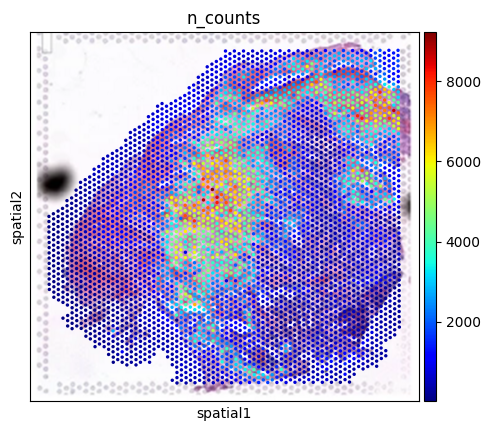

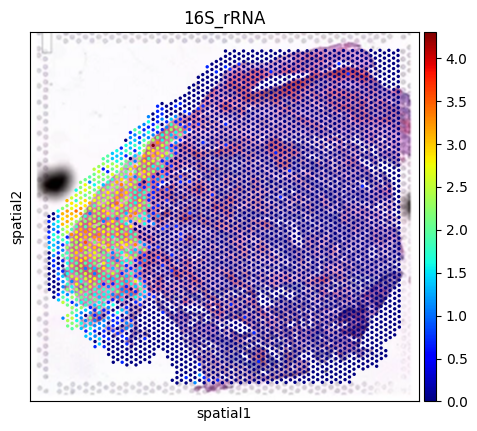

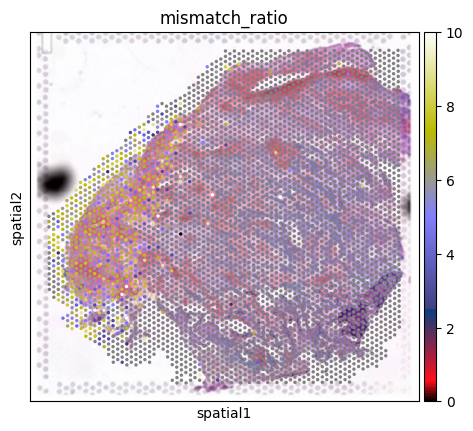

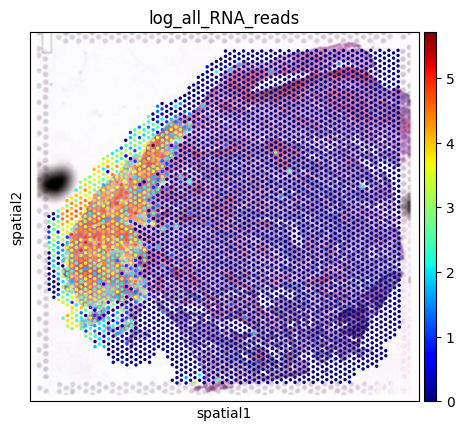

In [39]:
# 선택적으로, spatial plot 생성
# sc.pl.spatial(adata, color='new_flag')

filtered_adata = adata[adata.obs['new_flag'] == True]

sc.pl.spatial(filtered_adata, color = 'n_counts', cmap='jet')

sc.pl.spatial(filtered_adata, color = '16S_rRNA', cmap='jet')

import matplotlib.pyplot as plt
import scanpy as sc

cmap = plt.cm.gist_stern  # You can choose any other colormap
cmap.set_under('gray')  # Setting the color for -1 values

# Create the plot
sc.pl.spatial(filtered_adata, color='mismatch_ratio', cmap=cmap, vmax = 10, vmin=0, show=False)

# Save the figure in high resolution
plt.savefig('spatial_plot.png', dpi=300)  # 300 dpi is typically considered high resolution

sc.pl.spatial(filtered_adata, color = 'log_all_RNA_reads', cmap='jet')

In [41]:
# AnnData 객체를 'adata.h5ad' 파일로 저장
adata.write('OSCC_filtered_adata_240401.h5ad')


In [47]:
filtered_adata.obs

,in_tissue,array_row,array_col,n_counts,mask,all_RNA_reads,mean_num_of_mismatches,mismatch_ratio,log_all_RNA_reads,new_flag
AAACAACGAATAGTTC-1,1,0,16,2995.446777,In,0,0,-1.0,0.000000,True
AAACAAGTATCTCCCA-1,1,50,102,1849.946045,In,0,0,-1.0,0.000000,True
AAACAATCTACTAGCA-1,0,3,43,1762.702637,Out,0,0,-1.0,0.000000,True
AAACAGAGCGACTCCT-1,1,14,94,378.436981,In,0,0,-1.0,0.000000,True
AAACAGCTTTCAGAAG-1,0,43,9,673.846741,Out,0,0,-1.0,0.000000,True
...,...,...,...,...,...,...,...,...,...,...
TTGTTCTAGATACGCT-1,1,21,3,2449.936768,In,0,0,-1.0,0.000000,True
TTGTTGTGTGTCAAGA-1,1,31,77,1321.349487,In,0,0,-1.0,0.000000,True
TTGTTTCACATCCAGG-1,1,58,42,523.403320,In,2,6,3.0,1.098612,True
TTGTTTCCATACAACT-1,1,45,27,1652.234131,In,0,0,-1.0,0.000000,True


/home/seohyepark/yes/envs/CellDART/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


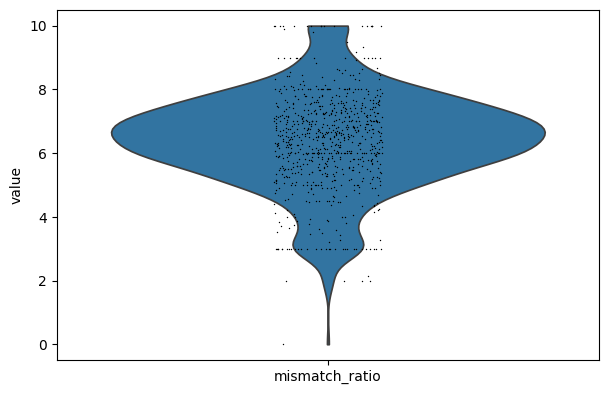

In [49]:
import scanpy as sc

# mismatch_ratio가 -1이 아닌 행만 필터링
filtered_data = filtered_adata[filtered_adata.obs['mismatch_ratio'] != -1].copy()

# 필터링된 데이터로 바이올린 플롯 그리기
sc.pl.violin(filtered_data, keys='mismatch_ratio')
